In [2]:
import os
import random
import numpy as np
import shutil

from PIL import Image, ImageEnhance

In [3]:
PROCESSED_DIR = "../dataset_processed"         # salinan untuk augmentasi
PROCESSED_AUG_DIR = "../dataset_processed_aug"  # folder: train/ val/ test/ per kelas

# Duplikat seluruh folder dataset_processed -> dataset_processed_aug
if os.path.exists(PROCESSED_AUG_DIR):
    shutil.rmtree(PROCESSED_AUG_DIR)  # hapus dulu jika sudah ada agar bersih

shutil.copytree(PROCESSED_DIR, PROCESSED_AUG_DIR)

print(f"Folder berhasil diduplikat:")
print(f"{PROCESSED_DIR} -> {PROCESSED_AUG_DIR}")


Folder berhasil diduplikat:
../dataset_processed -> ../dataset_processed_aug


### Augmentasi (Optional) 
augmentasi hanya untuk kelas minoritas.

In [4]:
# Hitung jumlah gambar per kelas di train/
train_dir = os.path.join(PROCESSED_AUG_DIR, "train")
class_counts = {cls: len(os.listdir(os.path.join(train_dir, cls)))
                for cls in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, cls))}

max_count = max(class_counts.values())
print("Jumlah gambar sebelum augmentasi:", class_counts)
print("Target setiap kelas:", max_count, "\n")

# Daftar jenis augmentasi (manual)
AUG_TYPES = ["flip", "flip_v", "bright", "dark", "zoom", "rotate"]

# Proses augmentasi hanya untuk kelas minoritas
for cls, count in class_counts.items():
    if count >= max_count:
        continue  # skip kelas mayoritas

    cls_path = os.path.join(train_dir, cls)
    images = [
        f for f in os.listdir(cls_path) 
        if f.lower().endswith(('.jpg', '.png', '.jpeg'))
    ]

    total_needed = max_count - count
    aug_per_image = max(1, total_needed // len(images))  # jumlah augment per gambar

    print(f"Augmenting {cls}: {count} asli, tambah {total_needed} total (~{aug_per_image} per gambar)")

    total_generated = 0
    for img_name in images:
        img_path = os.path.join(cls_path, img_name)
        base_name, ext = os.path.splitext(img_name)
        img_pil = Image.open(img_path).convert("RGB")
        img_np = np.expand_dims(np.array(img_pil), 0)

        # Tentukan jenis augmentasi acak
        for i in range(aug_per_image):
            aug_type = random.choice(AUG_TYPES)
            aug_img = img_pil.copy()

            if aug_type == "flip":
                aug_img = aug_img.transpose(Image.FLIP_LEFT_RIGHT)
            elif aug_type == "flip_v":
                aug_img = aug_img.transpose(Image.FLIP_TOP_BOTTOM)
            elif aug_type == "bright":
                enhancer = ImageEnhance.Brightness(aug_img)
                aug_img = enhancer.enhance(1.7)
            elif aug_type == "dark":
                enhancer = ImageEnhance.Brightness(aug_img)
                aug_img = enhancer.enhance(0.3)
            elif aug_type == "zoom":
                zoom_factor = random.uniform(1.3, 2)
                w, h = aug_img.size
                new_w, new_h = int(w / zoom_factor), int(h / zoom_factor)
                left = (w - new_w) // 2
                top = (h - new_h) // 2
                aug_img = aug_img.crop((left, top, left + new_w, top + new_h)).resize((w, h))
            elif aug_type == "rotate":
                aug_img = aug_img.rotate(random.randint(-20, 20), fillcolor=(128,128,128))

            # Simpan hasil dengan nama baru
            new_name = f"{base_name}_aug_{aug_type}_{i+1:02d}{ext.lower()}"
            aug_img.save(os.path.join(cls_path, new_name))
            total_generated += 1

            if total_generated >= total_needed:
                break
        if total_generated >= total_needed:
            break

print("\nAugmentasi merata selesai ✅\n")

# Cek ulang jumlah gambar  per kelas setelah augmentasi
final_counts = {cls: len(os.listdir(os.path.join(train_dir, cls)))
                for cls in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, cls))}
print("Jumlah gambar setelah augmentasi:", final_counts)


Jumlah gambar sebelum augmentasi: {'alur': 554, 'lubang': 496, 'retak': 352, 'tidak_rusak': 392}
Target setiap kelas: 554 

Augmenting lubang: 496 asli, tambah 58 total (~1 per gambar)
Augmenting retak: 352 asli, tambah 202 total (~1 per gambar)
Augmenting tidak_rusak: 392 asli, tambah 162 total (~1 per gambar)

Augmentasi merata selesai ✅

Jumlah gambar setelah augmentasi: {'alur': 554, 'lubang': 554, 'retak': 554, 'tidak_rusak': 554}


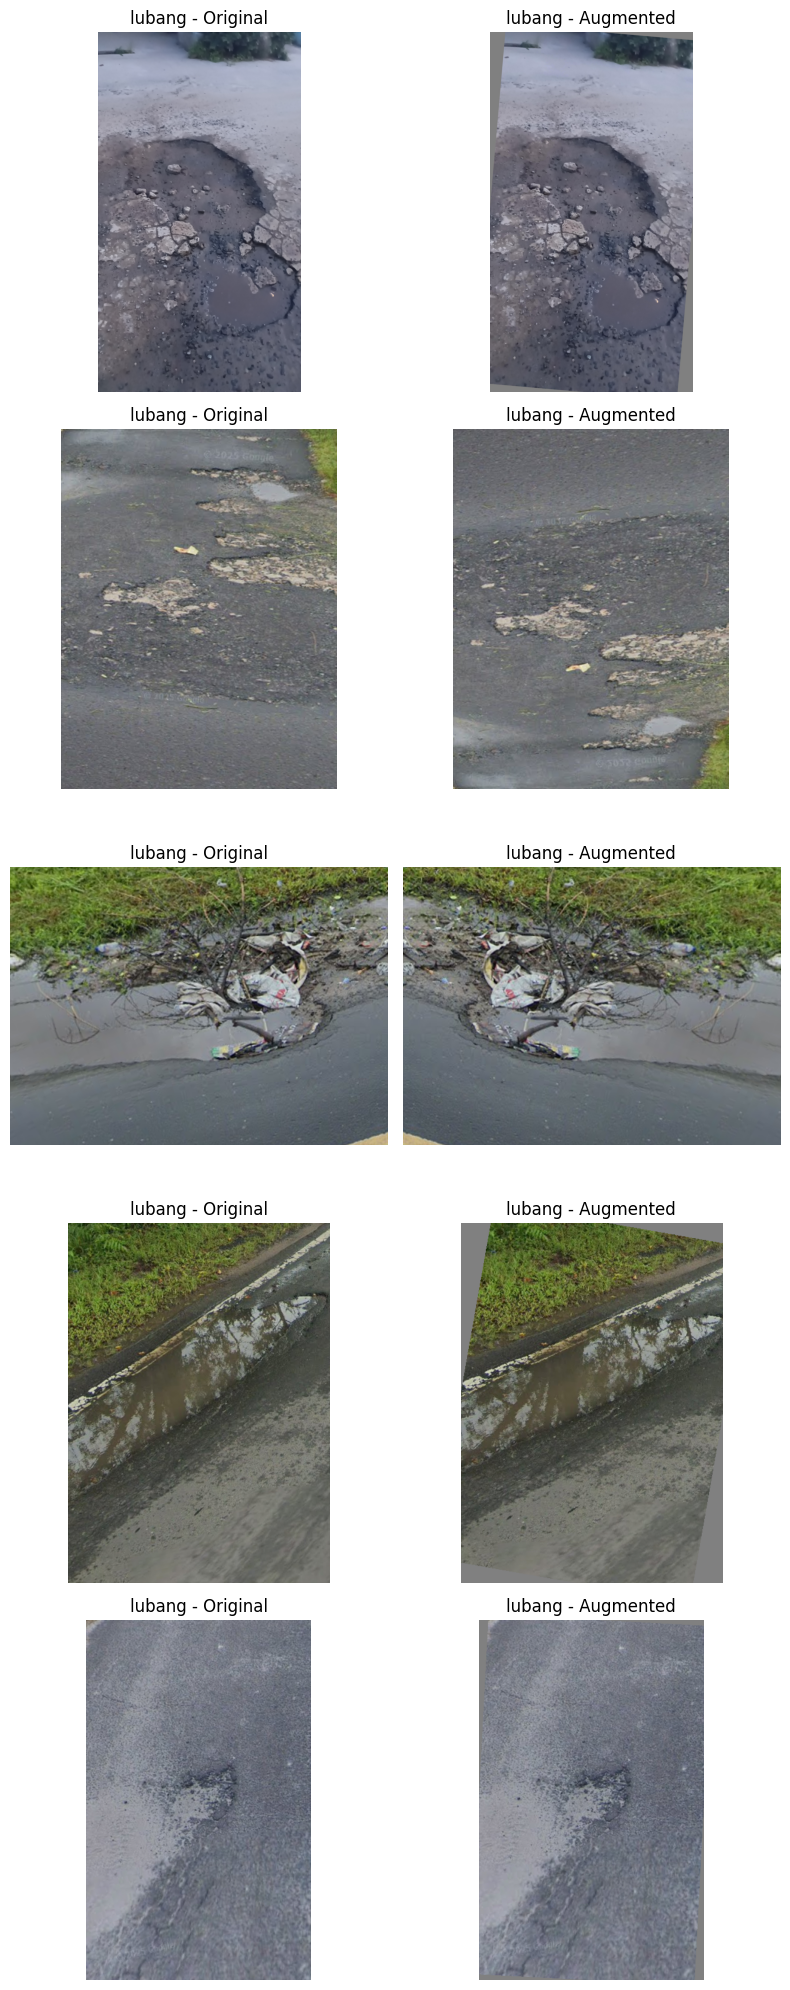

In [5]:
import matplotlib.pyplot as plt

# Ambil beberapa contoh gambar augmentasi
sample_pairs = []

for cls in os.listdir(train_dir):
    cls_path = os.path.join(train_dir, cls)

    if not os.path.isdir(cls_path):
        continue

    files = [f for f in os.listdir(cls_path)
             if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    # Cari file asli dan file augmentasinya
    originals = [f for f in files if "_aug_" not in f]
    augments = [f for f in files if "_aug_" in f]

    for orig in originals:
        base_name = os.path.splitext(orig)[0]

        # cari augment yang berasal dari gambar ini
        related_aug = [a for a in augments if a.startswith(base_name + "_aug_")]

        if related_aug:
            sample_pairs.append((
                cls,
                os.path.join(cls_path, orig),
                os.path.join(cls_path, random.choice(related_aug))
            ))

        if len(sample_pairs) >= 5:  # tampilkan 5 pasangan saja
            break

    if len(sample_pairs) >= 5:
        break

# Plot
fig, axes = plt.subplots(len(sample_pairs), 2, figsize=(8, 4 * len(sample_pairs)))

if len(sample_pairs) == 1:
    axes = [axes]

for idx, (cls, orig_path, aug_path) in enumerate(sample_pairs):
    orig_img = Image.open(orig_path)
    aug_img = Image.open(aug_path)

    axes[idx][0].imshow(orig_img)
    axes[idx][0].set_title(f"{cls} - Original")
    axes[idx][0].axis("off")

    axes[idx][1].imshow(aug_img)
    axes[idx][1].set_title(f"{cls} - Augmented")
    axes[idx][1].axis("off")

plt.tight_layout()
plt.show()